# 02 — Topological invariant and the $\eta$-independent edge weight

The winding number of `q(k)=t1+t2 e^{-ik}` (computed with a grid-robust
closed-loop estimator) gives `|nu|=1` for `t2>t1`. The **eta-independent**
topological observable is the boundary spectral weight `W0 = 1-(t1/t2)^2`.

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np, matplotlib.pyplot as plt
import nh_topo as nt
from nh_topo import plotting as P
cfg = nt.load_all(config_dir="../config"); p = nt.get_physics_params(cfg)
from pathlib import Path
def figdir(key): return Path("..") / nt.get_figure_dir(cfg, key)
print(f"t1={p['t1']}, t2={p['t2']}, gamma={p['gamma']}, N={p['N']}, "
      f"|nu|={nt.topological_invariant(p['t1'], p['t2'])}")

t1=0.8, t2=1.2, gamma=0.3, N=20, |nu|=1


winding is grid-independent: [-1.0, -1.0, -1.0]


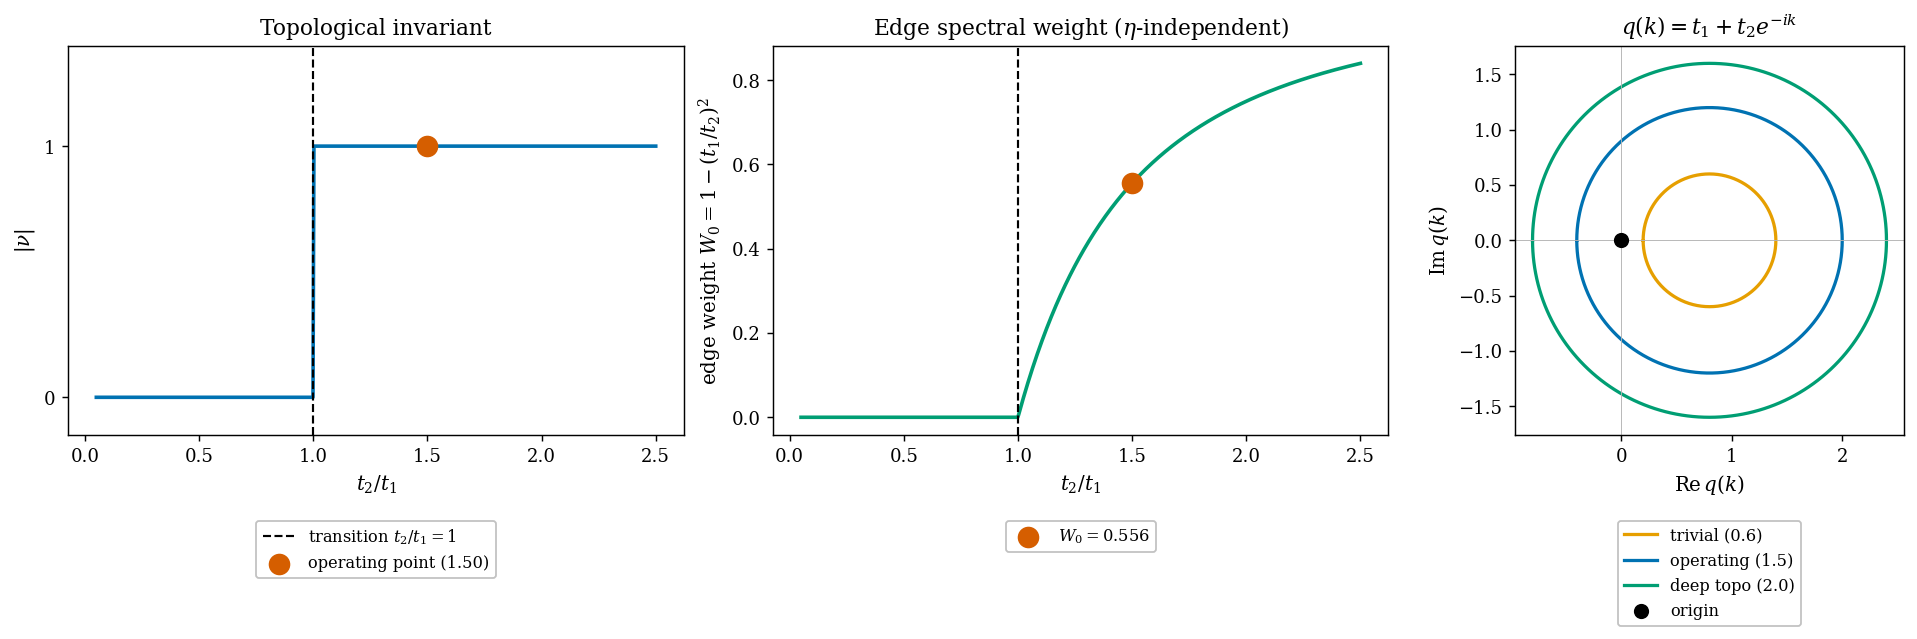

In [2]:
r = np.linspace(0.05, 2.5, 600)
nu = np.array([nt.topological_invariant(1.0, rv) for rv in r])
w0 = np.array([nt.analytic_edge_weight(1.0, rv) for rv in r])
cases = [("trivial (0.6)", P.C["trivial"], nt.qk_trajectory(p["t1"], 0.6)),
         (f"operating ({p['t2']/p['t1']:.1f})", P.C["edge"], nt.qk_trajectory(p["t1"], p["t2"])),
         ("deep topo (2.0)", P.C["topo"], nt.qk_trajectory(p["t1"], 2.0*p["t1"]))]
print("winding is grid-independent:",
      [round(nt.winding_number(p["t1"], p["t2"], nk), 6) for nk in (20, 200, 4000)])
fig, _ = P.plot_topology(p["t1"], p["t2"], r, nu, w0, cases)
P.save_fig(fig, figdir("02_topological_invariants"), "01_invariant_edgeweight"); plt.show()